In [1]:
from functools import partial

from superfv import HydroSolver, ics, BC

import matplotlib.pyplot as plt
import numpy as np

In [2]:
nu = 1e-3
cs = 1e-2

ic = partial(
    ics.velocity_shear_diffusion,
    v0=1.0,
    sigma0=0.1,
    x0=0.5,
    nu=nu,
    rho0=1.0,
    kappa=15.0,
    iso_cs=cs,
)

sim = HydroSolver(
    ic=ic,
    nu=nu,
    nx=64,
    p=0,
    bcx=(BC.IC, BC.IC),
    isothermal=True,
    iso_cs=cs,
)

In [3]:
sim.run(1.0)

SuperFV: 11 steps | t=1.00e+00/1.00e+00, dt=2.34e-02 | rho_min=3.57e-07 | E_cons=3.10e-05 | wall=5.63e-03s (done)


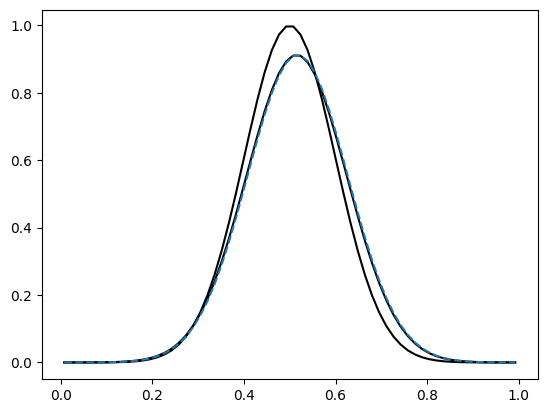

In [4]:
fig, ax = plt.subplots()

ax.plot(
    sim.mesh.centers[0], ic(sim.idx, *sim.mesh.Centers, 0.0, xp=np)[sim.idx("vy"), :, 0, 0], "k"
)
ax.plot(
    sim.mesh.centers[0], ic(sim.idx, *sim.mesh.Centers, sim.t, xp=np)[sim.idx("vy"), :, 0, 0], "k"
)
ax.plot(sim.mesh.centers[0], sim.snapshot_history[-1].w[sim.idx("vy"), :, 0, 0], "--")